In [128]:
from sklearn.datasets import make_classification
import numpy as np
import pandas as pd
import random

In [129]:
X,y=make_classification(n_features=5,n_redundant=0,n_informative=5,n_clusters_per_class=1)

In [130]:
df=pd.DataFrame(X,columns=['col1','col2','col3','col4','col5'])
df['target']=y
print(df.shape)
df.head()

(100, 6)


,col1,col2,col3,col4,col5,target
0,1.323834,-0.300380,1.492641,1.989906,1.638413,1
1,1.834576,-0.571260,-0.921191,1.640350,0.047687,1
2,0.631681,-1.037136,-0.769483,-0.178219,2.460329,1
3,2.210607,0.084414,-0.694536,-1.676377,2.176003,1
4,-1.943009,0.279885,-2.767064,5.030890,-2.627489,0


In [131]:
# Row Sampling
def sample_rows(df,percent):
    return df.sample(int(percent*df.shape[0]),replace=True)

#Featuring Sampling
def sample_features(df,percent):
    cols=random.sample(df.columns.tolist()[:-1],int(percent*df.shape[1]-1))
    new_df=df[cols]
    new_df['target']=df['target']
    return new_df

# for both
def combined_sampling(df,row_percent,col_percent):
    new_df=sample_rows(df,row_percent)
    return sample_features(new_df,col_percent)

In [132]:
df1=sample_rows(df,0.1)

In [133]:
df2=sample_rows(df,0.1)
df3=sample_rows(df,0.1)

In [134]:
from sklearn.tree import DecisionTreeClassifier
clf1=DecisionTreeClassifier()
clf2=DecisionTreeClassifier()
clf3=DecisionTreeClassifier()

In [135]:
from sklearn.tree import plot_tree

In [136]:
clf1.fit(df1.iloc[:,0:5],df1.iloc[:,-1])
clf2.fit(df2.iloc[:,0:5],df1.iloc[:,-1])
clf3.fit(df3.iloc[:,0:5],df1.iloc[:,-1])

,criterion,'gini'
,splitter,'best'
,max_depth,None
,min_samples_split,2
,min_samples_leaf,1
,min_weight_fraction_leaf,0.0
,max_features,None
,random_state,None
,max_leaf_nodes,None
,min_impurity_decrease,0.0
,class_weight,None


[Text(0.5, 0.75, 'x[1] <= -0.516\ngini = 0.5\nsamples = 10\nvalue = [5, 5]'),
 Text(0.25, 0.25, 'gini = 0.0\nsamples = 5\nvalue = [0, 5]'),
 Text(0.375, 0.5, 'True  '),
 Text(0.75, 0.25, 'gini = 0.0\nsamples = 5\nvalue = [5, 0]'),
 Text(0.625, 0.5, '  False')]

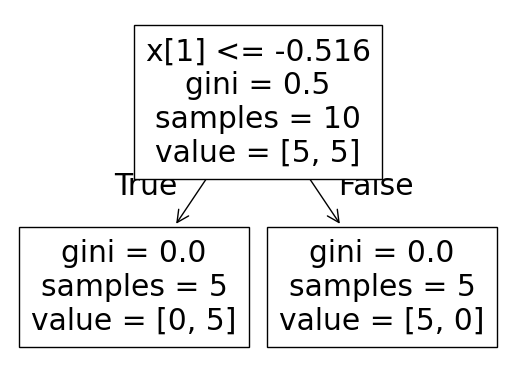

In [137]:
plot_tree(clf1)


[Text(0.6, 0.875, 'x[1] <= 1.013\ngini = 0.5\nsamples = 10\nvalue = [5, 5]'),
 Text(0.4, 0.625, 'x[0] <= -1.483\ngini = 0.408\nsamples = 7\nvalue = [5, 2]'),
 Text(0.5, 0.75, 'True  '),
 Text(0.2, 0.375, 'gini = 0.0\nsamples = 1\nvalue = [0, 1]'),
 Text(0.6, 0.375, 'x[1] <= -0.697\ngini = 0.278\nsamples = 6\nvalue = [5, 1]'),
 Text(0.4, 0.125, 'gini = 0.0\nsamples = 1\nvalue = [0, 1]'),
 Text(0.8, 0.125, 'gini = 0.0\nsamples = 5\nvalue = [5, 0]'),
 Text(0.8, 0.625, 'gini = 0.0\nsamples = 3\nvalue = [0, 3]'),
 Text(0.7, 0.75, '  False')]

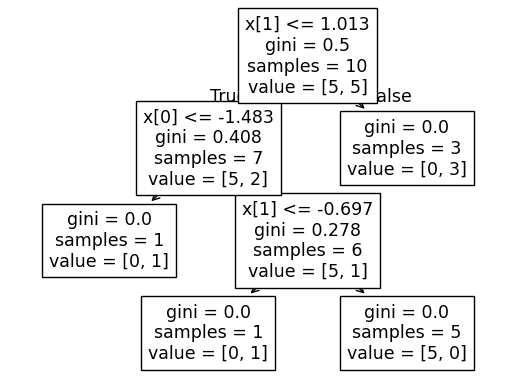

In [138]:
plot_tree(clf2)

[Text(0.4, 0.875, 'x[1] <= -1.161\ngini = 0.5\nsamples = 10\nvalue = [5, 5]'),
 Text(0.2, 0.625, 'gini = 0.0\nsamples = 3\nvalue = [0, 3]'),
 Text(0.30000000000000004, 0.75, 'True  '),
 Text(0.6, 0.625, 'x[4] <= -1.039\ngini = 0.408\nsamples = 7\nvalue = [5, 2]'),
 Text(0.5, 0.75, '  False'),
 Text(0.4, 0.375, 'x[4] <= -1.586\ngini = 0.444\nsamples = 3\nvalue = [1, 2]'),
 Text(0.2, 0.125, 'gini = 0.0\nsamples = 1\nvalue = [1, 0]'),
 Text(0.6, 0.125, 'gini = 0.0\nsamples = 2\nvalue = [0, 2]'),
 Text(0.8, 0.375, 'gini = 0.0\nsamples = 4\nvalue = [4, 0]')]

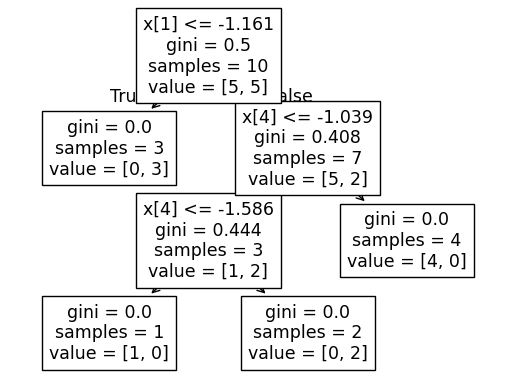

In [139]:
plot_tree(clf3)

In [140]:
print("clf1:",clf1.predict(np.array([1.126200,1.391025,-0.518545,-0.083527,1.370637]).reshape(1,5)))
print("clf2:",clf2.predict(np.array([1.126200,1.391025,-0.518545,-0.083527,1.370637]).reshape(1,5)))
print("clf3:",clf3.predict(np.array([1.126200,1.391025,-0.518545,-0.083527,1.370637]).reshape(1,5)))


clf1: [0]
clf2: [1]
clf3: [0]


C:\Users\Rishikesh Reddy\AppData\Roaming\Python\Python313\site-packages\sklearn\utils\validation.py:2749: UserWarning: X does not have valid feature names, but DecisionTreeClassifier was fitted with feature names
  warnings.warn(
C:\Users\Rishikesh Reddy\AppData\Roaming\Python\Python313\site-packages\sklearn\utils\validation.py:2749: UserWarning: X does not have valid feature names, but DecisionTreeClassifier was fitted with feature names
  warnings.warn(
C:\Users\Rishikesh Reddy\AppData\Roaming\Python\Python313\site-packages\sklearn\utils\validation.py:2749: UserWarning: X does not have valid feature names, but DecisionTreeClassifier was fitted with feature names
  warnings.warn(


In [141]:
df1=sample_features(df,0.8)
df2=sample_features(df,0.8)
df3=sample_features(df,0.8)
clf1.fit(df1.iloc[:,0:4],df1.iloc[:,-1])
clf2.fit(df2.iloc[:,0:4],df1.iloc[:,-1])
clf3.fit(df3.iloc[:,0:4],df1.iloc[:,-1])

C:\Users\Rishikesh Reddy\AppData\Local\Temp\ipykernel_14024\505982040.py:9: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  new_df['target']=df['target']
C:\Users\Rishikesh Reddy\AppData\Local\Temp\ipykernel_14024\505982040.py:9: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  new_df['target']=df['target']
C:\Users\Rishikesh Reddy\AppData\Local\Temp\ipykernel_14024\505982040.py:9: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] 

,criterion,'gini'
,splitter,'best'
,max_depth,None
,min_samples_split,2
,min_samples_leaf,1
,min_weight_fraction_leaf,0.0
,max_features,None
,random_state,None
,max_leaf_nodes,None
,min_impurity_decrease,0.0
,class_weight,None


[Text(0.5, 0.75, 'x[3] <= 0.5\ngini = 0.5\nsamples = 100\nvalue = [49, 51]'),
 Text(0.25, 0.25, 'gini = 0.0\nsamples = 49\nvalue = [49, 0]'),
 Text(0.375, 0.5, 'True  '),
 Text(0.75, 0.25, 'gini = 0.0\nsamples = 51\nvalue = [0, 51]'),
 Text(0.625, 0.5, '  False')]

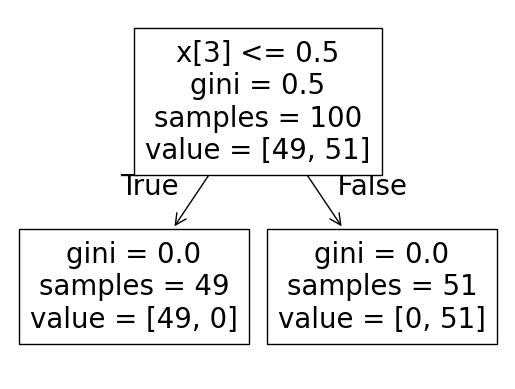

In [142]:
plot_tree(clf1)

[Text(0.5, 0.75, 'x[3] <= 0.5\ngini = 0.5\nsamples = 100\nvalue = [49, 51]'),
 Text(0.25, 0.25, 'gini = 0.0\nsamples = 49\nvalue = [49, 0]'),
 Text(0.375, 0.5, 'True  '),
 Text(0.75, 0.25, 'gini = 0.0\nsamples = 51\nvalue = [0, 51]'),
 Text(0.625, 0.5, '  False')]

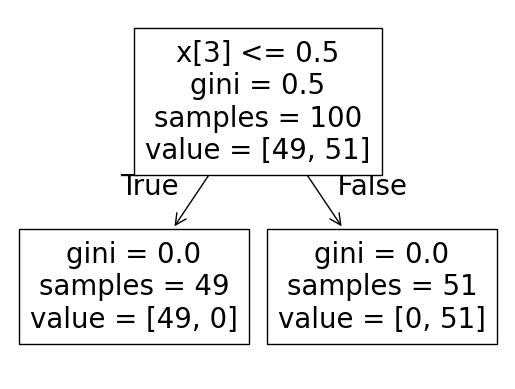

In [143]:
plot_tree(clf2)

[Text(0.5, 0.75, 'x[3] <= 0.5\ngini = 0.5\nsamples = 100\nvalue = [49, 51]'),
 Text(0.25, 0.25, 'gini = 0.0\nsamples = 49\nvalue = [49, 0]'),
 Text(0.375, 0.5, 'True  '),
 Text(0.75, 0.25, 'gini = 0.0\nsamples = 51\nvalue = [0, 51]'),
 Text(0.625, 0.5, '  False')]

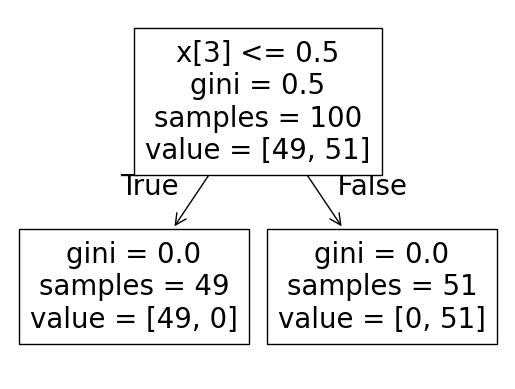

In [144]:
plot_tree(clf3)

In [145]:
print("clf1:",clf1.predict(np.array([1.126200,1.391025,-0.518545,-0.083527]).reshape(1,4)))
print("clf2:",clf2.predict(np.array([1.126200,1.391025,-0.518545,-0.083527]).reshape(1,4)))
print("clf3:",clf3.predict(np.array([1.126200,1.391025,-0.518545,-0.083527]).reshape(1,4)))

clf1: [0]
clf2: [0]
clf3: [0]


C:\Users\Rishikesh Reddy\AppData\Roaming\Python\Python313\site-packages\sklearn\utils\validation.py:2749: UserWarning: X does not have valid feature names, but DecisionTreeClassifier was fitted with feature names
  warnings.warn(
C:\Users\Rishikesh Reddy\AppData\Roaming\Python\Python313\site-packages\sklearn\utils\validation.py:2749: UserWarning: X does not have valid feature names, but DecisionTreeClassifier was fitted with feature names
  warnings.warn(
C:\Users\Rishikesh Reddy\AppData\Roaming\Python\Python313\site-packages\sklearn\utils\validation.py:2749: UserWarning: X does not have valid feature names, but DecisionTreeClassifier was fitted with feature names
  warnings.warn(


In [146]:
# for combined (Random Patches)
df1=combined_sampling(df,0.1,0.8)
df2=combined_sampling(df,0.1,0.8)
df3=combined_sampling(df,0.1,0.8)
clf1.fit(df1.iloc[:,0:4],df1.iloc[:,-1])
clf2.fit(df2.iloc[:,0:4],df1.iloc[:,-1])
clf3.fit(df3.iloc[:,0:4],df1.iloc[:,-1])

C:\Users\Rishikesh Reddy\AppData\Local\Temp\ipykernel_14024\505982040.py:9: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  new_df['target']=df['target']
C:\Users\Rishikesh Reddy\AppData\Local\Temp\ipykernel_14024\505982040.py:9: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  new_df['target']=df['target']
C:\Users\Rishikesh Reddy\AppData\Local\Temp\ipykernel_14024\505982040.py:9: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] 

,criterion,'gini'
,splitter,'best'
,max_depth,None
,min_samples_split,2
,min_samples_leaf,1
,min_weight_fraction_leaf,0.0
,max_features,None
,random_state,None
,max_leaf_nodes,None
,min_impurity_decrease,0.0
,class_weight,None


[Text(0.5, 0.75, 'x[2] <= -0.021\ngini = 0.48\nsamples = 10\nvalue = [4, 6]'),
 Text(0.25, 0.25, 'gini = 0.0\nsamples = 4\nvalue = [4, 0]'),
 Text(0.375, 0.5, 'True  '),
 Text(0.75, 0.25, 'gini = 0.0\nsamples = 6\nvalue = [0, 6]'),
 Text(0.625, 0.5, '  False')]

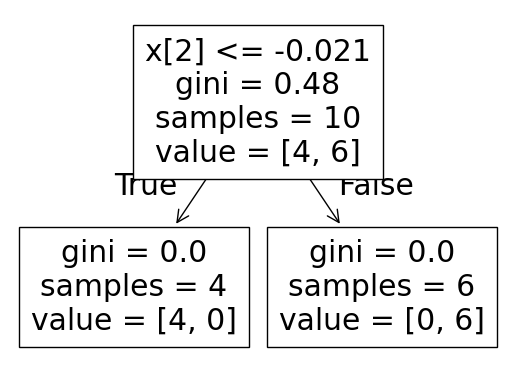

In [147]:
plot_tree(clf1)

[Text(0.6, 0.875, 'x[2] <= 1.763\ngini = 0.48\nsamples = 10\nvalue = [4, 6]'),
 Text(0.4, 0.625, 'x[0] <= -0.505\ngini = 0.375\nsamples = 8\nvalue = [2, 6]'),
 Text(0.5, 0.75, 'True  '),
 Text(0.2, 0.375, 'gini = 0.0\nsamples = 5\nvalue = [0, 5]'),
 Text(0.6, 0.375, 'x[0] <= -0.062\ngini = 0.444\nsamples = 3\nvalue = [2, 1]'),
 Text(0.4, 0.125, 'gini = 0.0\nsamples = 2\nvalue = [2, 0]'),
 Text(0.8, 0.125, 'gini = 0.0\nsamples = 1\nvalue = [0, 1]'),
 Text(0.8, 0.625, 'gini = 0.0\nsamples = 2\nvalue = [2, 0]'),
 Text(0.7, 0.75, '  False')]

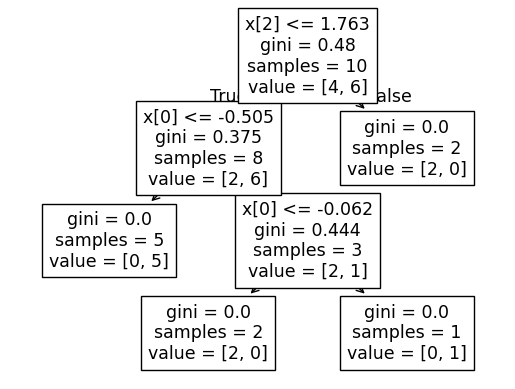

In [148]:
plot_tree(clf2)

[Text(0.5555555555555556, 0.875, 'x[1] <= 1.537\ngini = 0.48\nsamples = 10\nvalue = [4, 6]'),
 Text(0.3333333333333333, 0.625, 'x[0] <= -1.227\ngini = 0.278\nsamples = 6\nvalue = [1, 5]'),
 Text(0.4444444444444444, 0.75, 'True  '),
 Text(0.2222222222222222, 0.375, 'x[1] <= 1.026\ngini = 0.5\nsamples = 2\nvalue = [1, 1]'),
 Text(0.1111111111111111, 0.125, 'gini = 0.0\nsamples = 1\nvalue = [1, 0]'),
 Text(0.3333333333333333, 0.125, 'gini = 0.0\nsamples = 1\nvalue = [0, 1]'),
 Text(0.4444444444444444, 0.375, 'gini = 0.0\nsamples = 4\nvalue = [0, 4]'),
 Text(0.7777777777777778, 0.625, 'x[0] <= 0.852\ngini = 0.375\nsamples = 4\nvalue = [3, 1]'),
 Text(0.6666666666666667, 0.75, '  False'),
 Text(0.6666666666666666, 0.375, 'gini = 0.0\nsamples = 3\nvalue = [3, 0]'),
 Text(0.8888888888888888, 0.375, 'gini = 0.0\nsamples = 1\nvalue = [0, 1]')]

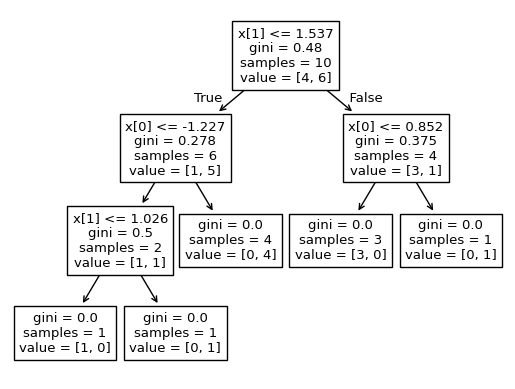

In [149]:
plot_tree(clf3)

In [ ]:
print("clf1:",clf1.predict(np.array([1.126200,1.391025,-0.518545,-0.083527]).reshape(1,4)))
print("clf2:",clf2.predict(np.array([1.126200,1.391025,-0.518545,-0.083527]).reshape(1,4)))
print("clf3:",clf3.predict(np.array([1.126200,1.391025,-0.518545,-0.083527]).reshape(1,4)))

clf1: [0]
clf2: [1]
clf3: [1]


C:\Users\Rishikesh Reddy\AppData\Roaming\Python\Python313\site-packages\sklearn\utils\validation.py:2749: UserWarning: X does not have valid feature names, but DecisionTreeClassifier was fitted with feature names
  warnings.warn(
C:\Users\Rishikesh Reddy\AppData\Roaming\Python\Python313\site-packages\sklearn\utils\validation.py:2749: UserWarning: X does not have valid feature names, but DecisionTreeClassifier was fitted with feature names
  warnings.warn(
C:\Users\Rishikesh Reddy\AppData\Roaming\Python\Python313\site-packages\sklearn\utils\validation.py:2749: UserWarning: X does not have valid feature names, but DecisionTreeClassifier was fitted with feature names
  warnings.warn(


: 